In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt

In [2]:
with open(f"../scripts/_cache/resnet18_imagenet_2_per_class_stability_vs_smoothing.json") as f:
    resnet18_saved = json.load(f)

with open(f"../scripts/_cache/resnet50_imagenet_2_per_class_stability_vs_smoothing.json") as f:
    resnet50_saved = json.load(f)

with open(f"../scripts/_cache/vit_imagenet_2_per_class_stability_vs_smoothing.json") as f:
    vit_saved = json.load(f)

with open(f"../scripts/_cache/roberta_tweeteval_sentiment_stability_vs_smoothing.json") as f:
    roberta_saved = json.load(f)

In [3]:
def make_plot(saved, title, legend_loc, fs=14):
    lambda_to_rates = saved["lambda_to_rates"]
    radii = saved["radii"]

    fig, ax = plt.subplots(figsize=(5,3))
    for k in [1.0, 0.8, 0.6, 0.4, 0.2]:
        ax.plot(radii, np.median(lambda_to_rates[f"{k:.3f}"], axis=0), label=f"$\lambda = {k:.1f}$")

    ax.set_ylabel("Stability Rate", fontsize=fs)
    ax.set_xlabel("Perturbation Radius", fontsize=fs)
    ax.tick_params(axis="x", labelsize=fs)
    ax.tick_params(axis="y", labelsize=fs)
    ax.set_xticks(radii)
    ax.legend(title=title, loc=legend_loc, title_fontsize=fs+2, fontsize=fs)
    return fig

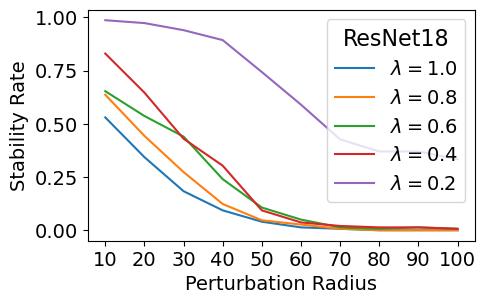

In [4]:
fig = make_plot(resnet18_saved, "ResNet18", legend_loc="upper right")
fig.savefig("_dump/stability_vs_smoothing_resnet18.pdf", bbox_inches="tight")

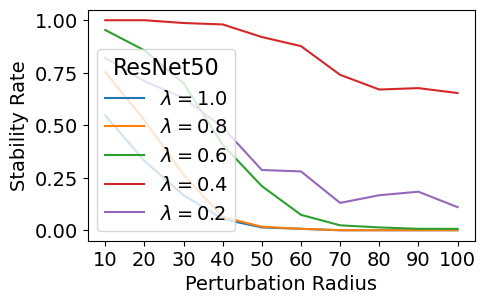

In [5]:
fig = make_plot(resnet50_saved, "ResNet50", legend_loc="lower left")
fig.savefig("_dump/stability_vs_smoothing_resnet50.pdf", bbox_inches="tight")

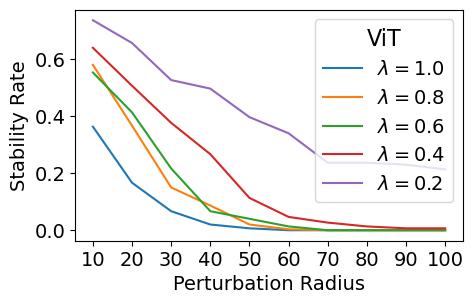

In [6]:
fig = make_plot(vit_saved, "ViT", legend_loc="upper right")
fig.savefig("_dump/stability_vs_smoothing_vit.pdf", bbox_inches="tight")

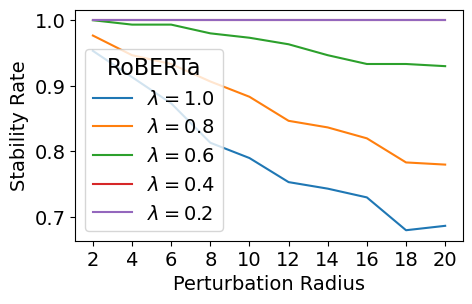

In [7]:
fig = make_plot(roberta_saved, "RoBERTa", legend_loc="lower left")
fig.savefig("_dump/stability_vs_smoothing_roberta.pdf", bbox_inches="tight")

In [8]:
def make_plot_with_quantiles(saved, key, label, title, color, fs=18):
    lambda_to_rates = saved["lambda_to_rates"]
    radii = saved["radii"]
    fig, ax = plt.subplots(figsize=(4,2))
    data = np.array(lambda_to_rates[key])
    qlo, qhi = np.quantile(data, [0.25, 0.75], axis=0)
    ax.plot(radii, np.median(data, axis=0), label=label, color=color)
    ax.fill_between(radii, qlo, qhi, alpha=0.2, color=color)
    
    ax.set_ylabel("Stability Rate", fontsize=fs)
    ax.set_xlabel("Perturbation Radius", fontsize=fs)
    ax.tick_params(axis="x", labelsize=fs)
    ax.tick_params(axis="y", labelsize=fs)
    ax.set_xticks([r for i, r in enumerate(radii) if i % 2 == 1])
    ax.legend(title=title, title_fontsize=fs, fontsize=fs)
    return fig

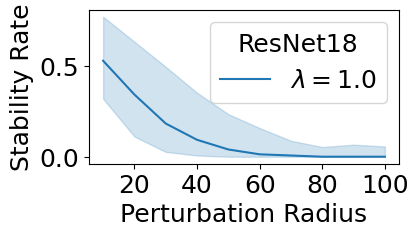

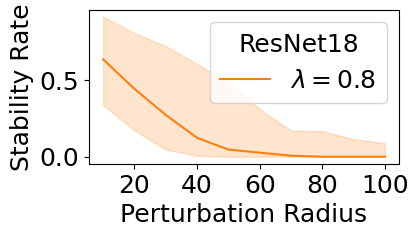

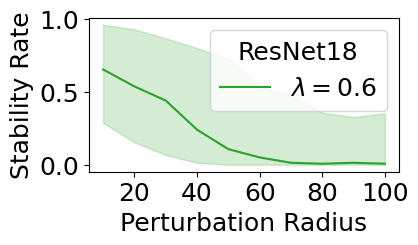

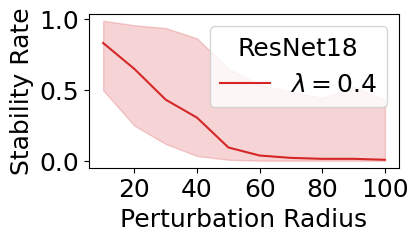

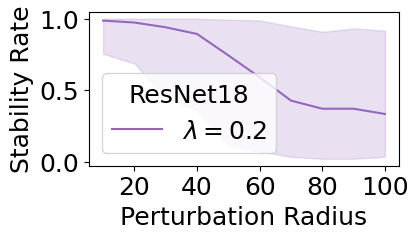

In [9]:
colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
keys = [1.0, 0.8, 0.6, 0.4, 0.2]
for i, k in enumerate(keys):
    fig = make_plot_with_quantiles(resnet18_saved, f"{k:.3f}", f"$\lambda = {k:.1f}$", "ResNet18", color=colors[i])
    fig.savefig(f"_dump/stability_vs_smoothing_resnet18_quantiles_{k:.1f}.pdf", bbox_inches="tight")

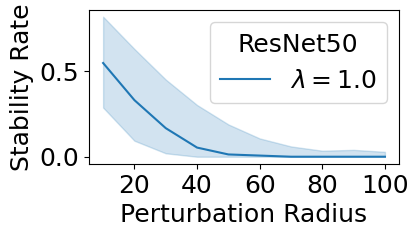

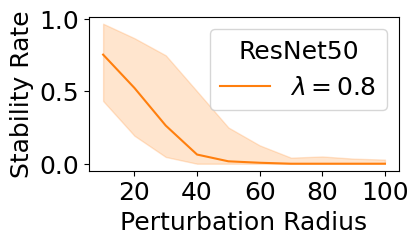

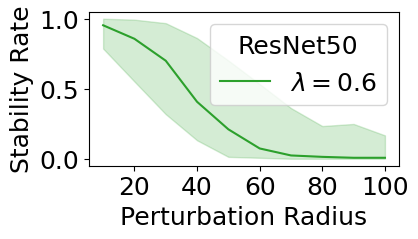

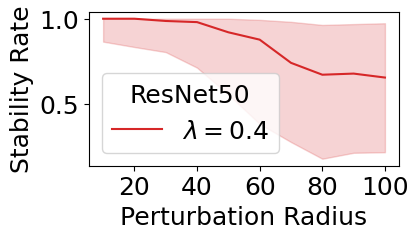

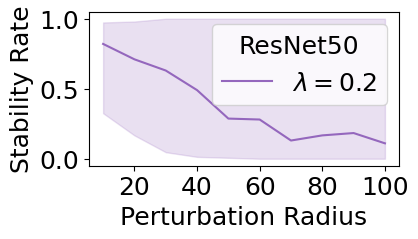

In [10]:
colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
keys = [1.0, 0.8, 0.6, 0.4, 0.2]
for i, k in enumerate(keys):
    fig = make_plot_with_quantiles(resnet50_saved, f"{k:.3f}", f"$\lambda = {k:.1f}$", "ResNet50", color=colors[i])
    fig.savefig(f"_dump/stability_vs_smoothing_resnet50_quantiles_{k:.1f}.pdf", bbox_inches="tight")

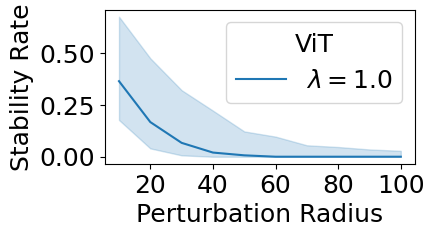

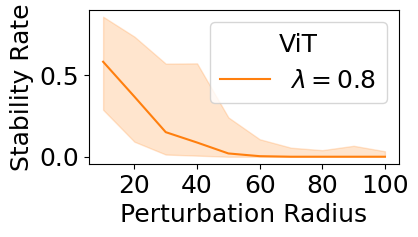

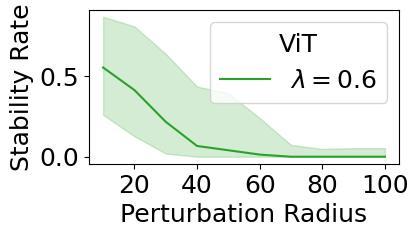

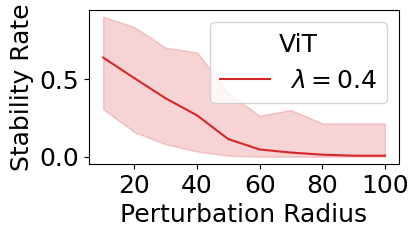

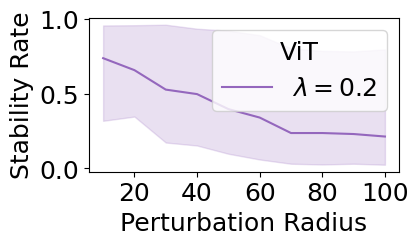

In [11]:
colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
keys = [1.0, 0.8, 0.6, 0.4, 0.2]
for i, k in enumerate(keys):
    fig = make_plot_with_quantiles(vit_saved, f"{k:.3f}", f"$\lambda = {k:.1f}$", "ViT", color=colors[i])
    fig.savefig(f"_dump/stability_vs_smoothing_vit_quantiles_{k:.1f}.pdf", bbox_inches="tight")

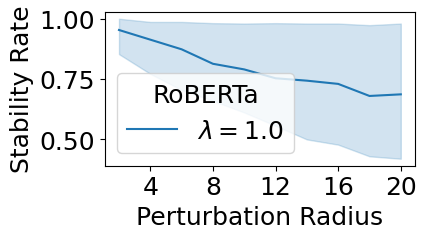

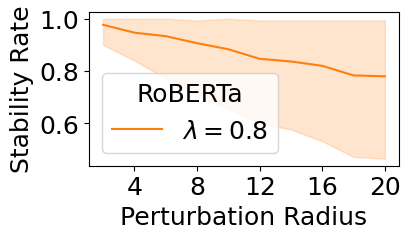

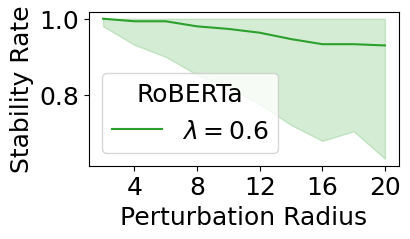

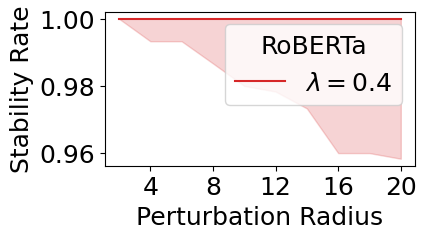

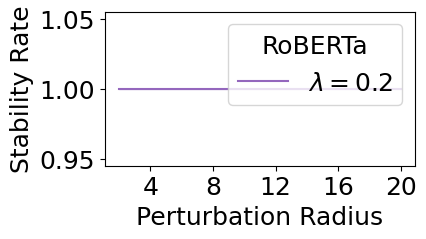

In [12]:
colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
keys = [1.0, 0.8, 0.6, 0.4, 0.2]
for i, k in enumerate(keys):
    fig = make_plot_with_quantiles(roberta_saved, f"{k:.3f}", f"$\lambda = {k:.1f}$", "RoBERTa", color=colors[i])
    fig.savefig(f"_dump/stability_vs_smoothing_roberta_quantiles_{k:.1f}.pdf", bbox_inches="tight")